Upload dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Spondylolisthesis Vertebral Landmark.zip to Spondylolisthesis Vertebral Landmark.zip


uploaded files

In [2]:
import os

print(os.listdir())

['.config', 'Spondylolisthesis Vertebral Landmark.zip', 'sample_data']


Unzip the dataset

In [3]:
import zipfile

zip_path = "Spondylolisthesis Vertebral Landmark.zip"
extract_path = "/content/spondy_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


dataset contents

In [4]:
import os

dataset_path = "/content/spondy_dataset"

print(os.listdir(dataset_path))

['Spondylolisthesis Vertebral Landmark']


Exploring folder structure

In [5]:
for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-"*40)

Folder: /content/spondy_dataset
Subfolders: ['Spondylolisthesis Vertebral Landmark']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/Spondylolisthesis Vertebral Landmark
Subfolders: []
Files: ['Dataset.zip']
----------------------------------------


In [6]:
import zipfile
import os

zip_path = "/content/spondy_dataset/Spondylolisthesis Vertebral Landmark/Dataset.zip"
extract_path = "/content/spondy_dataset/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
for root, dirs, files in os.walk("/content/spondy_dataset/dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-"*40)

Folder: /content/spondy_dataset/dataset
Subfolders: ['Dataset']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/dataset/Dataset
Subfolders: ['Train', 'Test']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/dataset/Dataset/Train
Subfolders: ['Keypointrcnn_data']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data
Subfolders: ['labels', 'images']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels
Subfolders: ['train', 'val']
Files: []
----------------------------------------
Folder: /content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train
Subfolders: []
Files: ['3789-F-033Y1_jpg.rf.83333d1cdb0446c49363311efe738110.txt', '4322-M-051Y1_jpg.rf.4ad43874a78ce2519d8ff9f57e5cf0e1.txt', '4078-F-043Y1_jpg.rf.bd3f304cb4088ac00e039dd1d966a366.txt', 'Screenshot-20

Count images

In [8]:
import os

image_extensions = ('.png', '.jpg', '.jpeg', '.bmp')

image_files = []

for root, dirs, files in os.walk("/content/spondy_dataset/dataset"):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Total X-ray images:", len(image_files))

Total X-ray images: 714


In [9]:
import os

train_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train"
val_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/val"
test_img_path = "/content/spondy_dataset/dataset/Dataset/Test"

image_exts = (".jpg", ".jpeg", ".png", ".bmp")

train_images = [f for f in os.listdir(train_img_path) if f.lower().endswith(image_exts)]
val_images = [f for f in os.listdir(val_img_path) if f.lower().endswith(image_exts)]
test_images = [f for f in os.listdir(test_img_path) if f.lower().endswith(image_exts)]

print("Training images :", len(train_images))
print("Validation images:", len(val_images))
print("Testing images   :", len(test_images))
print("Total images     :", len(train_images) + len(val_images) + len(test_images))

Training images : 494
Validation images: 204
Testing images   : 16
Total images     : 714


Show sample train images

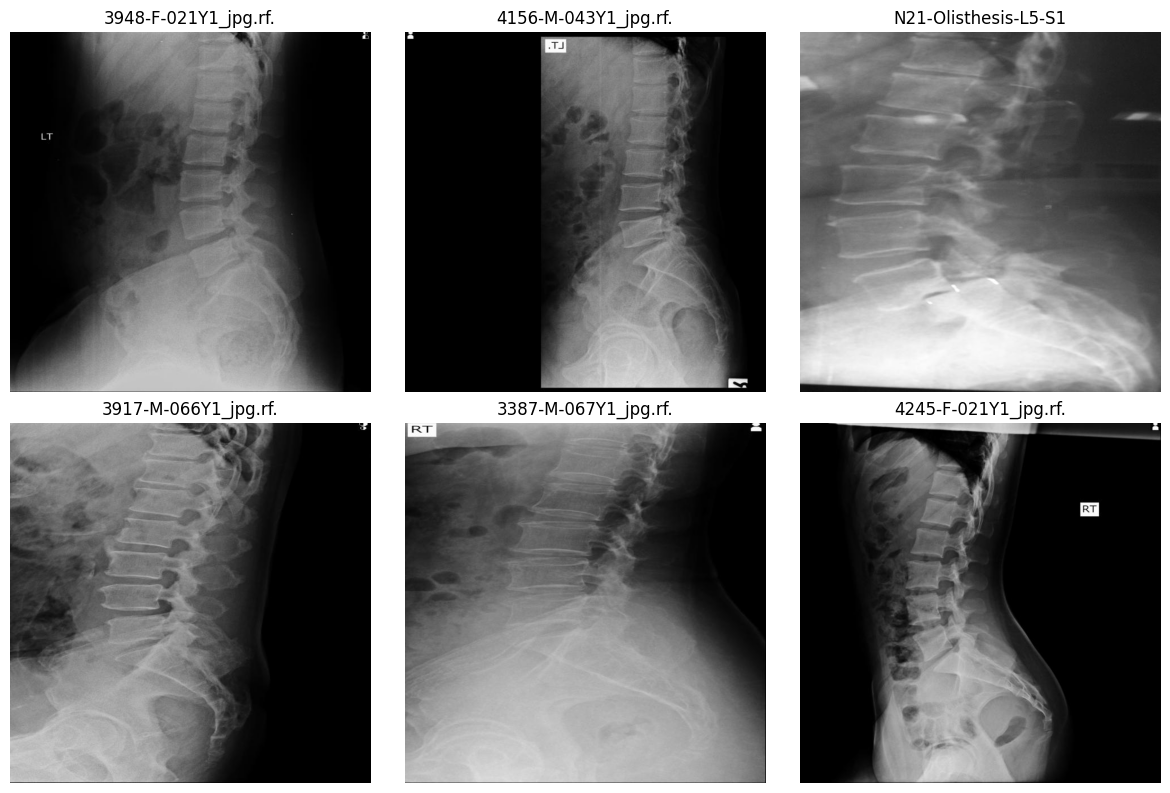

In [10]:
import cv2
import matplotlib.pyplot as plt
import random

sample_images = random.sample(train_images, min(6, len(train_images)))

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(train_img_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name[:20])
    plt.axis("off")

plt.tight_layout()
plt.show()

Check label file format

In [11]:
import os
import json

train_label_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train"

json_files = [f for f in os.listdir(train_label_path) if f.endswith(".json")]
txt_files = [f for f in os.listdir(train_label_path) if f.endswith(".txt")]

print("JSON label files:", len(json_files))
print("TXT label files :", len(txt_files))

# open one json file
sample_json = json_files[0]
print("\nSample JSON file:", sample_json)

with open(os.path.join(train_label_path, sample_json), "r") as f:
    data = json.load(f)

print(json.dumps(data, indent=2)[:3000])

JSON label files: 339
TXT label files : 155

Sample JSON file: Screenshot-2022-07-31-051211_jpg.rf.03dffb55b3f8fd77b467245c48305f0d.json
{
  "boxes": [
    [
      304,
      85,
      431,
      204
    ],
    [
      361,
      220,
      478,
      327
    ],
    [
      388,
      357,
      493,
      448
    ],
    [
      351,
      446,
      456,
      533
    ]
  ],
  "keypoints": [
    [
      [
        340,
        204,
        1
      ],
      [
        431,
        179,
        1
      ],
      [
        304,
        116,
        1
      ],
      [
        402,
        85,
        1
      ]
    ],
    [
      [
        380,
        327,
        1
      ],
      [
        478,
        309,
        1
      ],
      [
        361,
        235,
        1
      ],
      [
        456,
        220,
        1
      ]
    ],
    [
      [
        391,
        444,
        1
      ],
      [
        493,
        448,
        1
      ],
      [
        388,
        359,
        1
 

In [12]:
sample_txt = txt_files[0]
print("Sample TXT file:", sample_txt)

with open(os.path.join(train_label_path, sample_txt), "r") as f:
    print(f.read()[:2000])

Sample TXT file: 3789-F-033Y1_jpg.rf.83333d1cdb0446c49363311efe738110.txt
0 0.4203125 0.521875 0.17578125 0.13828125 0.34892231610337976 0.5011526165167621 2 0.37612117296222664 0.5701889615699101 2 0.45849483101391647 0.5241647587898609 2 0.442952634194831 0.47430515126737527 2
0 0.39296875 0.4296875 0.19296875 0.1 0.3403741053677933 0.39376279640228945 2 0.3403741053677933 0.46791291905151267 2 0.43828996023856853 0.454489165985282 2 0.439067097415507 0.3892881847914963 2
0 0.409375 0.325 0.16796875 0.12265625 0.3591469184890656 0.28967690106295996 2 0.3428485089463221 0.3591035977105478 2 0.44495233598409545 0.3714292313982011 2 0.45514666998011927 0.2999056827473426 2
0 0.43515625 0.23046875 0.1421875 0.1234375 0.408972365805169 0.19138716271463613 2 0.36939438369781313 0.2599511447260834 2 0.459943986083499 0.28856054783319707 2 0.49292564612326045 0.2165437448896157 2
0 0.46875 0.57890625 0.13828125 0.09375 0.5283059642147119 0.5716952166802944 2 0.4629423459244533 0.540126206050

Match one image with one label

In [13]:
print("Sample train image:", train_images[0])
print("Sample json label :", json_files[0] if len(json_files) > 0 else "No JSON")
print("Sample txt label  :", txt_files[0] if len(txt_files) > 0 else "No TXT")

Sample train image: Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg
Sample json label : Screenshot-2022-07-31-051211_jpg.rf.03dffb55b3f8fd77b467245c48305f0d.json
Sample txt label  : 3789-F-033Y1_jpg.rf.83333d1cdb0446c49363311efe738110.txt


In [14]:
import os

for root, dirs, files in os.walk("/content/spondy_dataset/dataset"):
    print(root, len(files))

/content/spondy_dataset/dataset 0
/content/spondy_dataset/dataset/Dataset 0
/content/spondy_dataset/dataset/Dataset/Train 0
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data 0
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels 0
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train 494
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/val 204
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images 0
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train 494
/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/val 204
/content/spondy_dataset/dataset/Dataset/Test 16


In [15]:
import os

train_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train"
train_label_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train"

json_files = [f for f in os.listdir(train_label_path) if f.endswith(".json")]
train_images = [f for f in os.listdir(train_img_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# try to match image and json by common prefix before .jpg/.json
for img_name in train_images:
    img_base = img_name.rsplit(".", 1)[0]
    for json_name in json_files:
        json_base = json_name.rsplit(".", 1)[0]
        if img_base == json_base:
            print("Matched image :", img_name)
            print("Matched label :", json_name)
            break

Matched image : Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg
Matched label : Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.json
Matched image : Screenshot-2022-07-31-053718_jpg.rf.79a556e6f0b4dbd84ff07a5cc902e4c5.jpg
Matched label : Screenshot-2022-07-31-053718_jpg.rf.79a556e6f0b4dbd84ff07a5cc902e4c5.json
Matched image : 3281-F-076Y1_jpg.rf.698b453d85c520a41e11455858b3b5ff.jpg
Matched label : 3281-F-076Y1_jpg.rf.698b453d85c520a41e11455858b3b5ff.json
Matched image : 3311-M-044Y1_jpg.rf.d9178aa710e2a6018f3658fa11013e3c.jpg
Matched label : 3311-M-044Y1_jpg.rf.d9178aa710e2a6018f3658fa11013e3c.json
Matched image : 3435-F-079Y1_jpg.rf.9a2fd1d530aa32b98a2f86fff8acd3be.jpg
Matched label : 3435-F-079Y1_jpg.rf.9a2fd1d530aa32b98a2f86fff8acd3be.json
Matched image : Screenshot-2022-07-31-051048_jpg.rf.09f13e77969340327944108add692124.jpg
Matched label : Screenshot-2022-07-31-051048_jpg.rf.09f13e77969340327944108add692124.json
Matched image : Screen

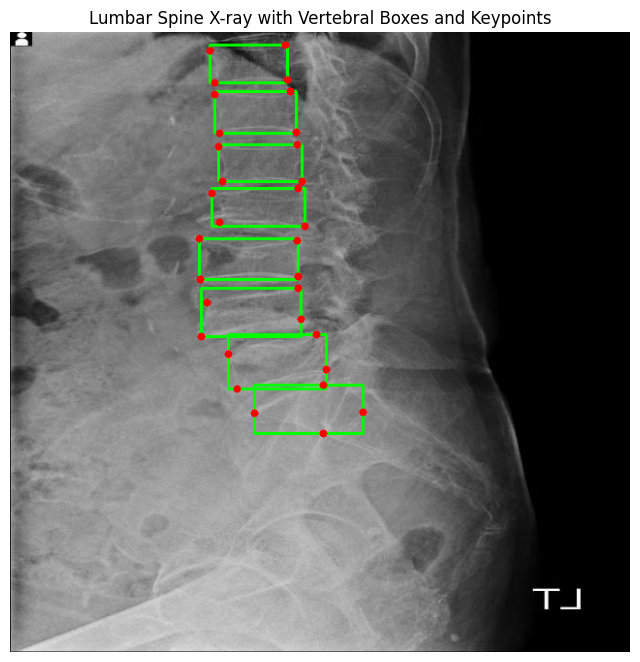

In [16]:
import os
import cv2
import json
import matplotlib.pyplot as plt

train_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train"
train_label_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train"

image_name = "3217-F-078Y1_jpg.rf.e6a43bd6a60a82c1da658e94463b3d42.jpg"
json_name = "3217-F-078Y1_jpg.rf.e6a43bd6a60a82c1da658e94463b3d42.json"

# load image
img_path = os.path.join(train_img_path, image_name)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# load json
json_path = os.path.join(train_label_path, json_name)
with open(json_path, "r") as f:
    ann = json.load(f)

boxes = ann["boxes"]
keypoints = ann["keypoints"]

# draw boxes and keypoints
img_draw = img.copy()

for box, kp_set in zip(boxes, keypoints):
    x1, y1, x2, y2 = box

    # draw bounding box
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # draw keypoints
    for kp in kp_set:
        x, y, v = kp
        if v > 0:
            cv2.circle(img_draw, (x, y), 4, (255, 0, 0), -1)

# show image
plt.figure(figsize=(8, 10))
plt.imshow(img_draw)
plt.title("Lumbar Spine X-ray with Vertebral Boxes and Keypoints")
plt.axis("off")
plt.show()

Load annotation file

In [17]:
import json

with open(json_path, "r") as f:
    ann = json.load(f)

boxes = ann["boxes"]
keypoints = ann["keypoints"]

Load image and annotation

In [18]:
import cv2
import json
import os
import matplotlib.pyplot as plt

img_path = os.path.join(train_img_path, image_name)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

json_path = os.path.join(train_label_path, json_name)

with open(json_path, "r") as f:
    ann = json.load(f)

boxes = ann["boxes"]
keypoints = ann["keypoints"]

Create ROI (lumbar region)

In [19]:
x_min = min([b[0] for b in boxes])
y_min = min([b[1] for b in boxes])
x_max = max([b[2] for b in boxes])
y_max = max([b[3] for b in boxes])

roi = img[y_min:y_max, x_min:x_max]

Draw vertebral bounding boxes

(np.float64(-0.5), np.float64(168.5), np.float64(400.5), np.float64(-0.5))

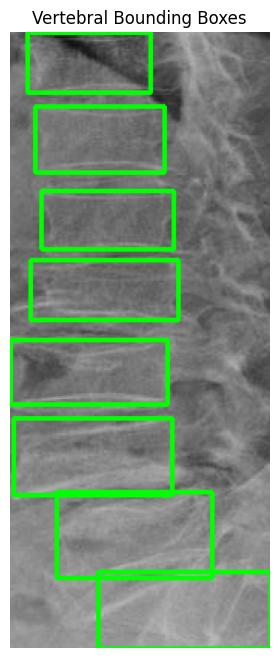

In [20]:
img_draw = roi.copy()

for box in boxes:

    x1, y1, x2, y2 = box

    # adjust coordinates relative to ROI
    x1 -= x_min
    x2 -= x_min
    y1 -= y_min
    y2 -= y_min

    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0,255,0), 2)

plt.figure(figsize=(6,8))
plt.imshow(img_draw)
plt.title("Vertebral Bounding Boxes")
plt.axis("off")

Draw vertebral landmarks

(np.float64(-0.5), np.float64(168.5), np.float64(400.5), np.float64(-0.5))

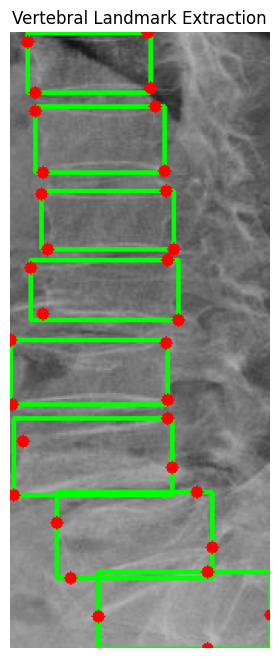

In [21]:
for kp_set in keypoints:

    for kp in kp_set:

        x, y, v = kp

        x -= x_min
        y -= y_min

        if v > 0:
            cv2.circle(img_draw, (int(x), int(y)), 4, (255,0,0), -1)

plt.figure(figsize=(6,8))
plt.imshow(img_draw)
plt.title("Vertebral Landmark Extraction")
plt.axis("off")

Image Normalization

In [22]:
roi_normalized = roi / 255.0

Data agumentation

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

Load image and annotation

In [24]:
import cv2
import json
import os
import matplotlib.pyplot as plt

img_path = os.path.join(train_img_path, image_name)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

json_path = os.path.join(train_label_path, json_name)

with open(json_path, "r") as f:
    ann = json.load(f)

boxes = ann["boxes"]
keypoints = ann["keypoints"]

extract roi

In [25]:
x_min = min([b[0] for b in boxes])
y_min = min([b[1] for b in boxes])
x_max = max([b[2] for b in boxes])
y_max = max([b[3] for b in boxes])

roi = img[y_min:y_max, x_min:x_max]

Draw vertebral bounding boxes

In [26]:
img_draw = roi.copy()

for box in boxes:

    x1, y1, x2, y2 = box

    x1 -= x_min
    x2 -= x_min
    y1 -= y_min
    y2 -= y_min

    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0,255,0), 2)

Plot vertebral keypoints

(np.float64(-0.5), np.float64(168.5), np.float64(400.5), np.float64(-0.5))

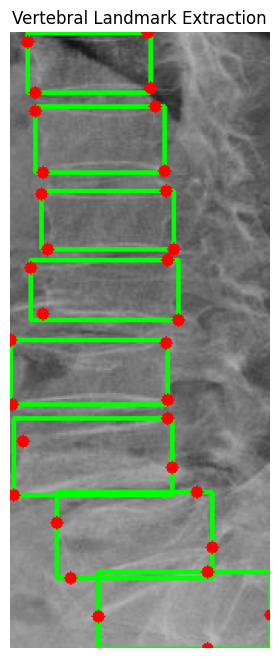

In [27]:
for kp_set in keypoints:

    for kp in kp_set:

        x, y, v = kp

        x -= x_min
        y -= y_min

        if v > 0:
            cv2.circle(img_draw, (int(x), int(y)), 4, (255,0,0), -1)

plt.figure(figsize=(6,8))
plt.imshow(img_draw)
plt.title("Vertebral Landmark Extraction")
plt.axis("off")

keypoints

In [28]:
import json

with open(json_path, "r") as f:
    ann = json.load(f)

keypoints = ann["keypoints"]

print(keypoints)

[[[211, 52, 1], [286, 49, 1], [206, 19, 1], [284, 13, 1]], [[216, 104, 1], [295, 103, 1], [211, 64, 1], [289, 61, 1]], [[219, 154, 1], [301, 154, 1], [215, 118, 1], [296, 116, 1]], [[216, 196, 1], [304, 200, 1], [208, 166, 1], [297, 161, 1]], [[196, 255, 1], [297, 252, 1], [195, 213, 1], [296, 215, 1]], [[197, 314, 1], [300, 296, 1], [203, 279, 1], [297, 264, 1]], [[234, 368, 1], [326, 348, 1], [225, 332, 1], [316, 312, 1]], [[323, 414, 1], [364, 392, 1], [252, 393, 1], [323, 364, 1]]]


load keypoints

In [29]:
import json
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(train_img_path, image_name)
json_path = os.path.join(train_label_path, json_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(json_path, "r") as f:
    ann = json.load(f)

boxes = ann["boxes"]
keypoints = ann["keypoints"]

In [30]:
x_min = min([b[0] for b in boxes])
y_min = min([b[1] for b in boxes])
x_max = max([b[2] for b in boxes])
y_max = max([b[3] for b in boxes])

roi = img[y_min:y_max, x_min:x_max]

compute vertebral centers

In [31]:
vertebral_centers = []

for box in boxes:
    x1, y1, x2, y2 = box
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    vertebral_centers.append((cx, cy))

print("Vertebral centers:")
print(vertebral_centers)

Vertebral centers:
[(246.0, 32.5), (253.0, 82.5), (258.0, 135.0), (256.0, 180.5), (246.0, 234.0), (248.5, 289.0), (275.5, 340.0), (308.0, 389.0)]


disc gap measurement

In [32]:
disc_gaps = []

for i in range(len(keypoints) - 1):
    upper = keypoints[i]
    lower = keypoints[i + 1]

    # bottom edge midpoint of upper vertebra
    upper_bottom_x = (upper[0][0] + upper[1][0]) / 2
    upper_bottom_y = (upper[0][1] + upper[1][1]) / 2

    # top edge midpoint of lower vertebra
    lower_top_x = (lower[2][0] + lower[3][0]) / 2
    lower_top_y = (lower[2][1] + lower[3][1]) / 2

    # Euclidean distance
    gap = np.sqrt((lower_top_x - upper_bottom_x)**2 + (lower_top_y - upper_bottom_y)**2)
    disc_gaps.append(gap)

print("Disc gap measurements:")
print(disc_gaps)

Disc gap measurements:
[np.float64(12.093386622447824), np.float64(13.5), np.float64(12.103718436910205), np.float64(21.592822881689184), np.float64(18.33712082089225), np.float64(27.80287754891569), np.float64(21.828879952943073)]


Inter-vertebral distance calculation

In [33]:
intervertebral_distances = []

for i in range(len(vertebral_centers) - 1):
    x1, y1 = vertebral_centers[i]
    x2, y2 = vertebral_centers[i + 1]

    dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    intervertebral_distances.append(dist)

print("Inter-vertebral distances:")
print(intervertebral_distances)

Inter-vertebral distances:
[np.float64(50.48762224545735), np.float64(52.73755777432247), np.float64(45.54393483220351), np.float64(54.42655601817921), np.float64(55.056788863863105), np.float64(57.706152185014034), np.float64(58.79838433154435)]


Visualize disc gaps and inter-vertebral distances

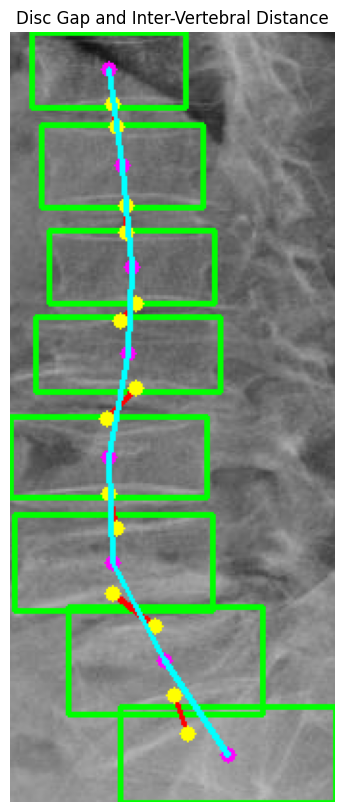

In [34]:
img_draw = roi.copy()

# draw vertebral boxes
for box in boxes:
    x1, y1, x2, y2 = box
    x1 -= x_min
    x2 -= x_min
    y1 -= y_min
    y2 -= y_min
    cv2.rectangle(img_draw, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

# draw disc gap lines
for i in range(len(keypoints) - 1):
    upper = keypoints[i]
    lower = keypoints[i + 1]

    upper_bottom_x = int((upper[0][0] + upper[1][0]) / 2) - x_min
    upper_bottom_y = int((upper[0][1] + upper[1][1]) / 2) - y_min

    lower_top_x = int((lower[2][0] + lower[3][0]) / 2) - x_min
    lower_top_y = int((lower[2][1] + lower[3][1]) / 2) - y_min

    cv2.line(img_draw, (upper_bottom_x, upper_bottom_y), (lower_top_x, lower_top_y), (255, 0, 0), 2)
    cv2.circle(img_draw, (upper_bottom_x, upper_bottom_y), 4, (255, 255, 0), -1)
    cv2.circle(img_draw, (lower_top_x, lower_top_y), 4, (255, 255, 0), -1)

# draw vertebral centers and center-to-center distances
for i in range(len(vertebral_centers)):
    cx, cy = vertebral_centers[i]
    cx = int(cx - x_min)
    cy = int(cy - y_min)
    cv2.circle(img_draw, (cx, cy), 4, (255, 0, 255), -1)

for i in range(len(vertebral_centers) - 1):
    x1, y1 = vertebral_centers[i]
    x2, y2 = vertebral_centers[i + 1]

    x1 = int(x1 - x_min)
    y1 = int(y1 - y_min)
    x2 = int(x2 - x_min)
    y2 = int(y2 - y_min)

    cv2.line(img_draw, (x1, y1), (x2, y2), (0, 255, 255), 2)

plt.figure(figsize=(8, 10))
plt.imshow(img_draw)
plt.title("Disc Gap and Inter-Vertebral Distance")
plt.axis("off")
plt.show()

In [35]:
avg_disc_gap = np.mean(disc_gaps)
avg_intervertebral_distance = np.mean(intervertebral_distances)

print("Average disc gap:", avg_disc_gap)
print("Average inter-vertebral distance:", avg_intervertebral_distance)

Average disc gap: 18.179829466256887
Average inter-vertebral distance: 53.536713750083436


Severity Label Generation

In [36]:
import os

train_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train"
train_label_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train"

images = [f for f in os.listdir(train_img_path) if f.endswith(".jpg")]
json_files = [f for f in os.listdir(train_label_path) if f.endswith(".json")]

image_dict = {img.split(".jpg")[0]: img for img in images}
json_dict = {js.split(".json")[0]: js for js in json_files}

matched_pairs = [(image_dict[k], json_dict[k]) for k in image_dict if k in json_dict]

print("Matched pairs:", len(matched_pairs))
print("Example:", matched_pairs[0])

Matched pairs: 339
Example: ('Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg', 'Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.json')


In [37]:
import json
import numpy as np

dataset_labels = []

for image_name, json_name in matched_pairs:

    json_path = os.path.join(train_label_path, json_name)

    with open(json_path, "r") as f:
        ann = json.load(f)

    keypoints = ann["keypoints"]

    disc_gaps = []

    for i in range(len(keypoints) - 1):

        upper = keypoints[i]
        lower = keypoints[i + 1]

        upper_bottom_x = (upper[0][0] + upper[1][0]) / 2
        upper_bottom_y = (upper[0][1] + upper[1][1]) / 2

        lower_top_x = (lower[2][0] + lower[3][0]) / 2
        lower_top_y = (lower[2][1] + lower[3][1]) / 2

        gap = np.sqrt((lower_top_x - upper_bottom_x)**2 +
                      (lower_top_y - upper_bottom_y)**2)

        disc_gaps.append(gap)

    avg_gap = np.mean(disc_gaps)

    dataset_labels.append((image_name, avg_gap))

In [38]:
all_gaps = [item[1] for item in dataset_labels]

print("Min gap:", min(all_gaps))
print("Max gap:", max(all_gaps))

Min gap: 10.869134571258737
Max gap: 82.24308551882032


In [39]:
gaps = np.array(all_gaps)

moderate_th = np.percentile(gaps, 33)
normal_th = np.percentile(gaps, 66)

print("Moderate threshold:", moderate_th)
print("Normal threshold:", normal_th)

Moderate threshold: 17.76074398581245
Normal threshold: 26.5858037096158


In [40]:
def assign_severity(avg_gap):
    if avg_gap >= normal_th:
        return "Normal"
    elif avg_gap >= moderate_th:
        return "Moderate"
    else:
        return "Severe"

In [41]:
dataset_labels_final = []

for image_name, avg_gap in dataset_labels:
    label = assign_severity(avg_gap)
    dataset_labels_final.append((image_name, avg_gap, label))

print(dataset_labels_final[:5])

[('Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg', np.float64(51.616710731302), 'Normal'), ('Screenshot-2022-07-31-053718_jpg.rf.79a556e6f0b4dbd84ff07a5cc902e4c5.jpg', np.float64(28.62592737445269), 'Normal'), ('3281-F-076Y1_jpg.rf.698b453d85c520a41e11455858b3b5ff.jpg', np.float64(15.023540994738777), 'Severe'), ('3311-M-044Y1_jpg.rf.d9178aa710e2a6018f3658fa11013e3c.jpg', np.float64(20.57776171625498), 'Moderate'), ('3435-F-079Y1_jpg.rf.9a2fd1d530aa32b98a2f86fff8acd3be.jpg', np.float64(12.469900250890545), 'Severe')]


In [42]:
from collections import Counter

label_counts = Counter([label for _, _, label in dataset_labels_final])

print("Class distribution:")
print(label_counts)

Class distribution:
Counter({'Normal': 115, 'Severe': 112, 'Moderate': 112})


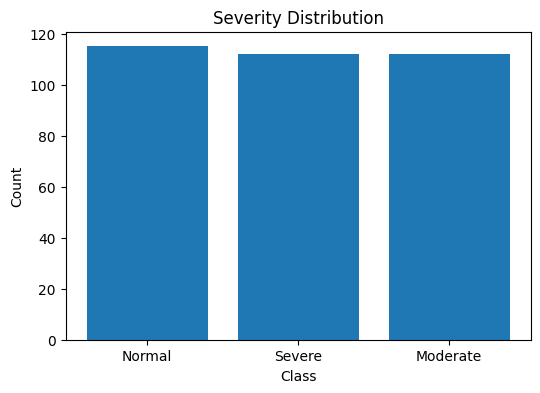

In [43]:
import matplotlib.pyplot as plt

classes = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Severity Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Generate labels for multiple images

In [44]:
import os

train_img_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/images/train"
train_label_path = "/content/spondy_dataset/dataset/Dataset/Train/Keypointrcnn_data/labels/train"

images = [f for f in os.listdir(train_img_path) if f.endswith(".jpg")]
json_files = [f for f in os.listdir(train_label_path) if f.endswith(".json")]

# match based on file name prefix
image_dict = {img.split(".jpg")[0]: img for img in images}
json_dict = {js.split(".json")[0]: js for js in json_files}

matched_pairs = []

for key in image_dict:
    if key in json_dict:
        matched_pairs.append((image_dict[key], json_dict[key]))

print("Total matched image-label pairs:", len(matched_pairs))
print("Example pair:", matched_pairs[0])

Total matched image-label pairs: 339
Example pair: ('Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg', 'Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.json')


In [45]:
dataset_labels = []

for image_name, json_name in matched_pairs:

    json_path = os.path.join(train_label_path, json_name)

    with open(json_path, "r") as f:
        ann = json.load(f)

    keypoints = ann["keypoints"]

    disc_gaps = []

    for i in range(len(keypoints)-1):

        upper = keypoints[i]
        lower = keypoints[i+1]

        upper_bottom_x = (upper[0][0] + upper[1][0]) / 2
        upper_bottom_y = (upper[0][1] + upper[1][1]) / 2

        lower_top_x = (lower[2][0] + lower[3][0]) / 2
        lower_top_y = (lower[2][1] + lower[3][1]) / 2

        gap = ((lower_top_x-upper_bottom_x)**2 + (lower_top_y-upper_bottom_y)**2)**0.5
        disc_gaps.append(gap)

    avg_gap = sum(disc_gaps)/len(disc_gaps)
    label = assign_severity(avg_gap)

    dataset_labels.append((image_name, avg_gap, label))

print(dataset_labels[:5])

[('Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg', 51.616710731302, 'Normal'), ('Screenshot-2022-07-31-053718_jpg.rf.79a556e6f0b4dbd84ff07a5cc902e4c5.jpg', 28.62592737445269, 'Normal'), ('3281-F-076Y1_jpg.rf.698b453d85c520a41e11455858b3b5ff.jpg', 15.023540994738777, 'Severe'), ('3311-M-044Y1_jpg.rf.d9178aa710e2a6018f3658fa11013e3c.jpg', 20.57776171625498, 'Moderate'), ('3435-F-079Y1_jpg.rf.9a2fd1d530aa32b98a2f86fff8acd3be.jpg', 12.469900250890545, 'Severe')]


Count number of images in each class

In [46]:
from collections import Counter

label_counts = Counter([label for _, _, label in dataset_labels])

print("Class distribution:")
print(label_counts)

Class distribution:
Counter({'Normal': 115, 'Severe': 112, 'Moderate': 112})


Plot class distribution

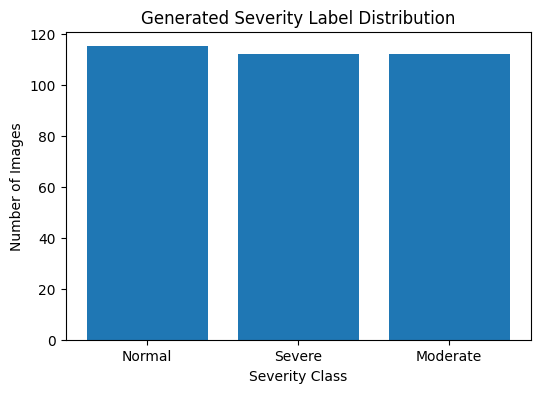

In [47]:
import matplotlib.pyplot as plt

classes = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Generated Severity Label Distribution")
plt.xlabel("Severity Class")
plt.ylabel("Number of Images")
plt.show()

Minimum gap: 10.869134571258737
Maximum gap: 82.24308551882032
Mean gap   : 26.144382306280004


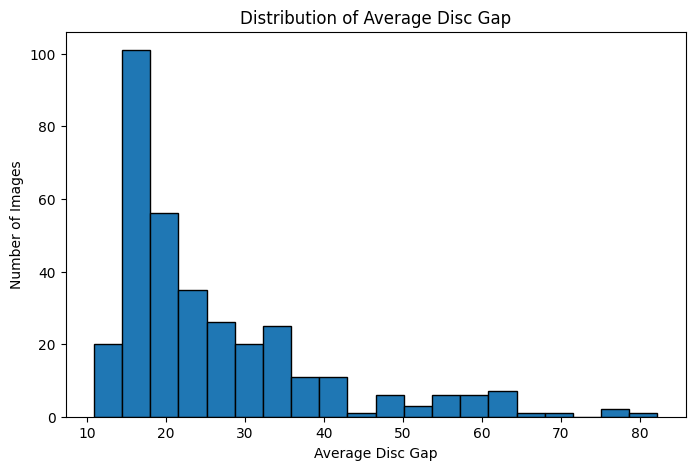

In [48]:
import matplotlib.pyplot as plt
import numpy as np

all_gaps = [item[1] for item in dataset_labels]

print("Minimum gap:", min(all_gaps))
print("Maximum gap:", max(all_gaps))
print("Mean gap   :", np.mean(all_gaps))

plt.figure(figsize=(8,5))
plt.hist(all_gaps, bins=20, edgecolor='black')
plt.title("Distribution of Average Disc Gap")
plt.xlabel("Average Disc Gap")
plt.ylabel("Number of Images")
plt.show()

In [49]:
gaps = np.array(all_gaps)

moderate_th = np.percentile(gaps, 33)
normal_th = np.percentile(gaps, 66)

print("Moderate threshold:", moderate_th)
print("Normal threshold  :", normal_th)

Moderate threshold: 17.76074398581245
Normal threshold  : 26.585803709615803


In [50]:
def assign_severity(avg_gap):
    if avg_gap >= normal_th:
        return "Normal"
    elif avg_gap >= moderate_th:
        return "Moderate"
    else:
        return "Severe"

In [51]:
dataset_labels = []

for image_name, json_name in matched_pairs:
    json_path = os.path.join(train_label_path, json_name)

    with open(json_path, "r") as f:
        ann = json.load(f)

    keypoints = ann["keypoints"]
    disc_gaps = []

    for i in range(len(keypoints)-1):
        upper = keypoints[i]
        lower = keypoints[i+1]

        upper_bottom_x = (upper[0][0] + upper[1][0]) / 2
        upper_bottom_y = (upper[0][1] + upper[1][1]) / 2

        lower_top_x = (lower[2][0] + lower[3][0]) / 2
        lower_top_y = (lower[2][1] + lower[3][1]) / 2

        gap = ((lower_top_x - upper_bottom_x)**2 + (lower_top_y - upper_bottom_y)**2) ** 0.5
        disc_gaps.append(gap)

    avg_gap = sum(disc_gaps) / len(disc_gaps)
    label = assign_severity(avg_gap)

    dataset_labels.append((image_name, avg_gap, label))

print(dataset_labels[:5])

[('Screenshot-2022-07-31-050932_jpg.rf.2d2ff766afa98ee58238e83c6f3f7ec1.jpg', 51.616710731302, 'Normal'), ('Screenshot-2022-07-31-053718_jpg.rf.79a556e6f0b4dbd84ff07a5cc902e4c5.jpg', 28.62592737445269, 'Normal'), ('3281-F-076Y1_jpg.rf.698b453d85c520a41e11455858b3b5ff.jpg', 15.023540994738777, 'Severe'), ('3311-M-044Y1_jpg.rf.d9178aa710e2a6018f3658fa11013e3c.jpg', 20.57776171625498, 'Moderate'), ('3435-F-079Y1_jpg.rf.9a2fd1d530aa32b98a2f86fff8acd3be.jpg', 12.469900250890545, 'Severe')]


In [52]:
from collections import Counter

label_counts = Counter([label for _, _, label in dataset_labels])

print("New class distribution:")
print(label_counts)

New class distribution:
Counter({'Normal': 115, 'Severe': 112, 'Moderate': 112})


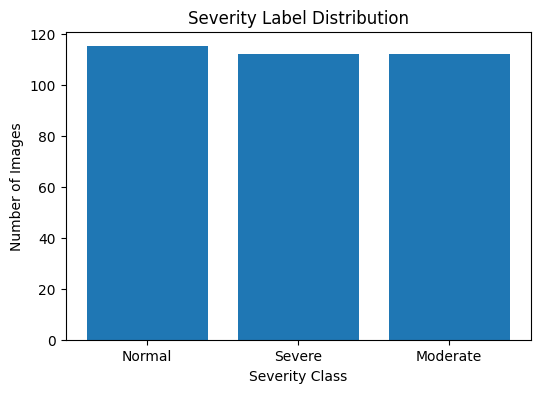

In [53]:
classes = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Severity Label Distribution")
plt.xlabel("Severity Class")
plt.ylabel("Number of Images")
plt.show()

Prepare Data for Swin Transformer

Create image path + label table

In [54]:
import pandas as pd
import os

data_rows = []

for image_name, avg_gap, label in dataset_labels:
    img_path = os.path.join(train_img_path, image_name)
    data_rows.append([img_path, avg_gap, label])

df = pd.DataFrame(data_rows, columns=["image_path", "avg_gap", "label"])

print(df.head())
print("\nTotal samples:", len(df))

                                          image_path    avg_gap     label
0  /content/spondy_dataset/dataset/Dataset/Train/...  51.616711    Normal
1  /content/spondy_dataset/dataset/Dataset/Train/...  28.625927    Normal
2  /content/spondy_dataset/dataset/Dataset/Train/...  15.023541    Severe
3  /content/spondy_dataset/dataset/Dataset/Train/...  20.577762  Moderate
4  /content/spondy_dataset/dataset/Dataset/Train/...  12.469900    Severe

Total samples: 339


Encode labels into numbers

In [55]:
label_map = {
    "Normal": 0,
    "Moderate": 1,
    "Severe": 2
}

df["label_id"] = df["label"].map(label_map)

print(df.head())

                                          image_path    avg_gap     label  \
0  /content/spondy_dataset/dataset/Dataset/Train/...  51.616711    Normal   
1  /content/spondy_dataset/dataset/Dataset/Train/...  28.625927    Normal   
2  /content/spondy_dataset/dataset/Dataset/Train/...  15.023541    Severe   
3  /content/spondy_dataset/dataset/Dataset/Train/...  20.577762  Moderate   
4  /content/spondy_dataset/dataset/Dataset/Train/...  12.469900    Severe   

   label_id  
0         0  
1         0  
2         2  
3         1  
4         2  


Load and preprocess images

In [56]:
import cv2
import numpy as np

IMG_SIZE = 224

def load_and_preprocess_image(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0
    return img

convert dataset into arrays

In [57]:
X = []
y = []

for _, row in df.iterrows():
    img = load_and_preprocess_image(row["image_path"], size=(IMG_SIZE, IMG_SIZE))
    X.append(img)
    y.append(row["label_id"])

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (339, 224, 224, 3)
y shape: (339,)


Train-validation split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)

Training set: (271, 224, 224, 3) (271,)
Validation set: (68, 224, 224, 3) (68,)


encode labels

In [59]:
from tensorflow.keras.utils import to_categorical

num_classes = 3

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)

y_train_cat shape: (271, 3)
y_val_cat shape: (68, 3)


Visualize a few training images with labels

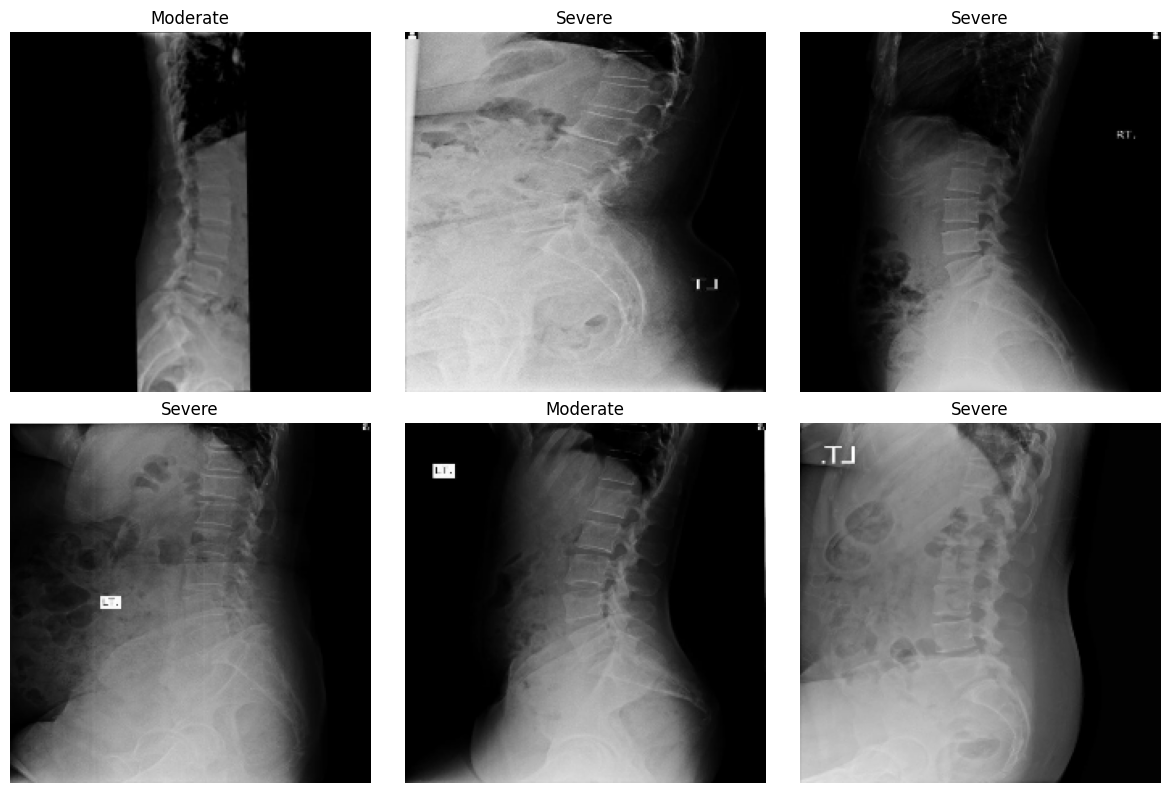

In [60]:
import matplotlib.pyplot as plt
import random

class_names = {0: "Normal", 1: "Moderate", 2: "Severe"}

indices = random.sample(range(len(X_train)), 6)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train[idx])
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Model Training

In [61]:
!pip install transformers timm torch torchvision

In [62]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
from transformers import SwinModel
import matplotlib.pyplot as plt

In [63]:
data_rows = []

for image_name, avg_gap, label in dataset_labels_final:
    img_path = os.path.join(train_img_path, image_name)
    data_rows.append([img_path, avg_gap, label])

df = pd.DataFrame(data_rows, columns=["image_path", "avg_gap", "label"])

label_map = {
    "Normal": 0,
    "Moderate": 1,
    "Severe": 2
}

df["label_id"] = df["label"].map(label_map)

# ADD THIS
gap_mean = df["avg_gap"].mean()
gap_std = df["avg_gap"].std()
df["avg_gap"] = (df["avg_gap"] - gap_mean) / gap_std

print(df.head())

                                          image_path   avg_gap     label  \
0  /content/spondy_dataset/dataset/Dataset/Train/...  1.922553    Normal   
1  /content/spondy_dataset/dataset/Dataset/Train/...  0.187297    Normal   
2  /content/spondy_dataset/dataset/Dataset/Train/... -0.839358    Severe   
3  /content/spondy_dataset/dataset/Dataset/Train/... -0.420147  Moderate   
4  /content/spondy_dataset/dataset/Dataset/Train/... -1.032097    Severe   

   label_id  
0         0  
1         0  
2         2  
3         1  
4         2  


In [64]:
osteophyte_labels = []

for _, avg_gap, label in dataset_labels_final:

    if label == "Severe":
        osteophyte_labels.append(1)

    elif label == "Moderate" and avg_gap < normal_th:
        osteophyte_labels.append(1)

    else:
        osteophyte_labels.append(0)

print("Sample osteophyte labels:", osteophyte_labels[:10])

Sample osteophyte labels: [0, 0, 1, 1, 1, 0, 0, 1, 0, 1]


In [65]:
df["osteophyte"] = osteophyte_labels

In [66]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 271
Validation samples: 68


In [67]:
class LumbarMultiTaskDataset(Dataset):
    def __init__(self, dataframe, img_size=224):
        self.df = dataframe
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img / 255.0

        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        class_label = torch.tensor(row["label_id"], dtype=torch.long)
        reg_target = torch.tensor(row["avg_gap"], dtype=torch.float32)
        osteo_label = torch.tensor(row["osteophyte"], dtype=torch.float32)

        return img, class_label, reg_target, osteo_label

In [68]:
train_dataset = LumbarMultiTaskDataset(train_df, img_size=IMG_SIZE)
val_dataset = LumbarMultiTaskDataset(val_df, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 34
Val batches: 9


Consistency Regularization

In [69]:
import torchvision.transforms as transforms

augment = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

Building the multi-task swim model

In [130]:
import torch
import torch.nn as nn
from transformers import SwinModel

class MultiTaskSwinModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # -----------------------------
        # 1. Swin Transformer Backbone
        # -----------------------------
        self.backbone = SwinModel.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224"
        )

        hidden_size = self.backbone.config.hidden_size

        # -----------------------------
        # 2. Shared layers
        # -----------------------------
        self.dropout = nn.Dropout(0.3)

        # -----------------------------
        # 3. Task Heads
        # -----------------------------

        # Classification (Normal / Moderate / Severe)
        self.classifier = nn.Linear(hidden_size, num_classes)

        # Regression (Disc Gap)
        self.regressor = nn.Linear(hidden_size, 1)

        # Osteophyte Detection (Binary)
        self.osteophyte_head = nn.Linear(hidden_size, 1)

    def forward(self, x):

        # -----------------------------
        # Backbone forward
        # -----------------------------
        outputs = self.backbone(pixel_values=x)

        # pooled feature representation
        features = outputs.pooler_output

        features = self.dropout(features)

        # -----------------------------
        # Outputs
        # -----------------------------

        # Classification
        class_logits = self.classifier(features)

        # Regression
        reg_output = self.regressor(features).squeeze(1)

        # Osteophyte detection (sigmoid)
        osteophyte_output = torch.sigmoid(
            self.osteophyte_head(features)
        )

        return class_logits, reg_output, osteophyte_output

In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskSwinModel(num_classes=3).to(device)

print("Model loaded on:", device)

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


In [100]:
criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
criterion_osteo = nn.BCELoss()

In [101]:
osteophyte_labels = []

for _, avg_gap, label in dataset_labels_final:
    if label == "Severe":
        osteophyte_labels.append(1)
    elif label == "Moderate" and avg_gap < normal_th:
        osteophyte_labels.append(1)
    else:
        osteophyte_labels.append(0)

df["osteophyte"] = osteophyte_labels

print(df.head())
print(df["osteophyte"].value_counts())

                                          image_path   avg_gap     label  \
0  /content/spondy_dataset/dataset/Dataset/Train/...  1.922553    Normal   
1  /content/spondy_dataset/dataset/Dataset/Train/...  0.187297    Normal   
2  /content/spondy_dataset/dataset/Dataset/Train/... -0.839358    Severe   
3  /content/spondy_dataset/dataset/Dataset/Train/... -0.420147  Moderate   
4  /content/spondy_dataset/dataset/Dataset/Train/... -1.032097    Severe   

   label_id  osteophyte  
0         0           0  
1         0           0  
2         2           1  
3         1           1  
4         2           1  
osteophyte
1    224
0    115
Name: count, dtype: int64


In [102]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 271
Validation samples: 68


In [103]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 271
Validation samples: 68


In [104]:
from torch.utils.data import DataLoader

train_dataset = LumbarMultiTaskDataset(train_df, img_size=IMG_SIZE)
val_dataset = LumbarMultiTaskDataset(val_df, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 34
Val batches: 9


In [105]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskSwinModel(num_classes=3).to(device)

criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
criterion_osteo = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=3e-5)

print("Using device:", device)

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda


In [106]:
import torchvision.transforms as transforms

augment = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

In [150]:
from sklearn.metrics import mean_squared_error

epochs = 30

train_losses = []
val_accuracies = []
val_mse_scores = []
val_osteo_accuracies = []

best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, class_labels, reg_targets, osteo_labels in train_loader:
        images = images.to(device)
        class_labels = class_labels.to(device)
        reg_targets = reg_targets.to(device)
        osteo_labels = osteo_labels.to(device).unsqueeze(1)

        # original prediction
        class_logits, reg_output, osteo_output = model(images)

        # augmented prediction
        aug_images = torch.stack([augment(img.cpu()).to(device) for img in images])
        class_logits_aug, reg_output_aug, osteo_output_aug = model(aug_images)

        # main losses
        loss_cls = criterion_cls(class_logits, class_labels)
        loss_reg = criterion_reg(reg_output, reg_targets)
        loss_osteo = criterion_osteo(osteo_output, osteo_labels)

        # consistency losses
        consistency_loss_cls = nn.MSELoss()(class_logits, class_logits_aug)
        consistency_loss_reg = nn.MSELoss()(reg_output, reg_output_aug)
        consistency_loss_osteo = nn.MSELoss()(osteo_output, osteo_output_aug)

        # total loss
        loss = (
            loss_cls
            + 0.01 * loss_reg
            + 0.1 * loss_osteo
            + 0.1 * consistency_loss_cls
            + 0.01 * consistency_loss_reg
            + 0.05 * consistency_loss_osteo
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation
    model.eval()
    correct = 0
    total = 0
    all_reg_preds = []
    all_reg_true = []
    all_osteo_preds = []
    all_osteo_true = []

    with torch.no_grad():
        for images, class_labels, reg_targets, osteo_labels in val_loader:
            images = images.to(device)
            class_labels = class_labels.to(device)
            reg_targets = reg_targets.to(device)
            osteo_labels = osteo_labels.to(device).unsqueeze(1)

            class_logits, reg_output, osteo_output = model(images)

            preds = torch.argmax(class_logits, dim=1)
            correct += (preds == class_labels).sum().item()
            total += class_labels.size(0)

            all_reg_preds.extend(reg_output.cpu().numpy())
            all_reg_true.extend(reg_targets.cpu().numpy())

            osteo_preds = (osteo_output > 0.5).int().cpu().numpy()
            all_osteo_preds.extend(osteo_preds.flatten())
            all_osteo_true.extend(osteo_labels.cpu().numpy().flatten())

    val_acc = correct / total
    val_mse = mean_squared_error(all_reg_true, all_reg_preds)
    val_osteo_acc = np.mean(np.array(all_osteo_preds) == np.array(all_osteo_true))

    val_accuracies.append(val_acc)
    val_mse_scores.append(val_mse)
    val_osteo_accuracies.append(val_osteo_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_multitask_swin_full.pth")

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.4f} - Val MSE: {val_mse:.4f} - Osteophyte Acc: {val_osteo_acc:.4f}")

Epoch 1/30 - Train Loss: 0.3318 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 2/30 - Train Loss: 0.3311 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 3/30 - Train Loss: 0.3093 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 4/30 - Train Loss: 0.3249 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 5/30 - Train Loss: 0.3283 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 6/30 - Train Loss: 0.3315 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 7/30 - Train Loss: 0.3442 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 8/30 - Train Loss: 0.3240 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 9/30 - Train Loss: 0.3393 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 10/30 - Train Loss: 0.3304 - Val Acc: 0.8676 - Val MSE: 0.3556 - Osteophyte Acc: 0.9853
Epoch 11/30 - Train Loss: 0.3365 - Val Acc: 0.8676 - Val MSE: 0.3556 

In [151]:
model.load_state_dict(torch.load("best_multitask_swin_full.pth"))
model.eval()

print("Best model loaded.")

Best model loaded.


In [152]:
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error

# Initialize lists outside the loop to accumulate predictions and true labels across all batches
all_cls_preds = []
all_cls_true = []
all_reg_preds = []
all_reg_true = []
all_osteo_preds = []
all_osteo_true = []
all_probs = [] # Initialize all_probs list

with torch.no_grad():
    for images, class_labels, reg_targets, osteo_labels in val_loader:
        images = images.to(device)

        class_logits, reg_output, osteo_output = model(images)

        # Classification predictions and probabilities
        cls_preds = torch.argmax(class_logits, dim=1).cpu().numpy()
        cls_probs = torch.softmax(class_logits, dim=1).cpu().numpy() # Calculate softmax probabilities
        all_cls_preds.extend(cls_preds)
        all_cls_true.extend(class_labels.numpy())
        all_probs.extend(np.max(cls_probs, axis=1)) # Append the maximum probability for each prediction

        all_reg_preds.extend(reg_output.cpu().numpy())
        all_reg_true.extend(reg_targets.numpy())

        osteo_preds = (osteo_output > 0.5).int().cpu().numpy().flatten()
        all_osteo_preds.extend(osteo_preds)
        all_osteo_true.extend(osteo_labels.numpy())

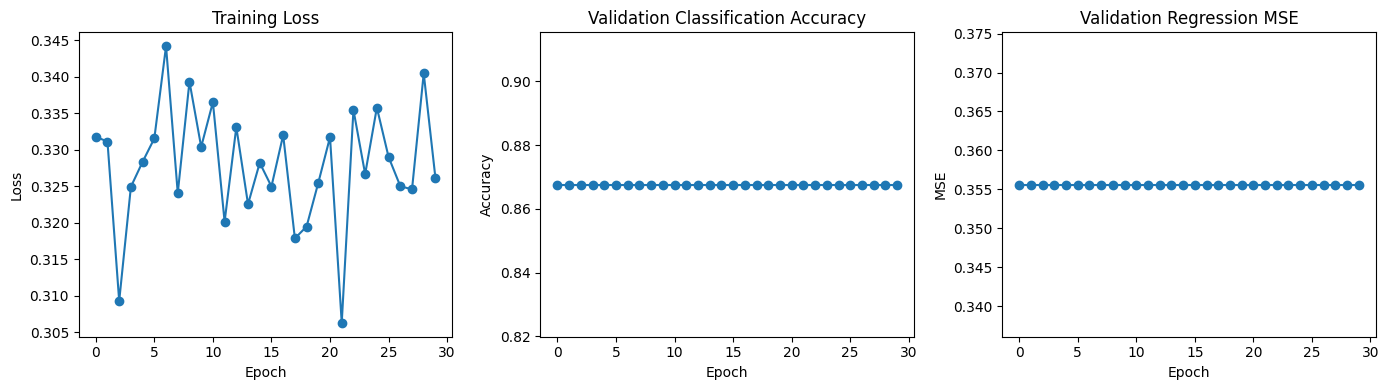

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,3,2)
plt.plot(val_accuracies, marker='o')
plt.title("Validation Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1,3,3)
plt.plot(val_mse_scores, marker='o')
plt.title("Validation Regression MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.tight_layout()
plt.show()

confidence estimation

In [154]:
confidences = np.array(all_probs)

print("First 10 confidence scores:")
print(confidences[:10])

First 10 confidence scores:
[0.80634713 0.7685373  0.8308847  0.8063041  0.9638395  0.6301091
 0.69897157 0.74569845 0.72230494 0.80539626]


Uncertainty estimation

In [155]:
uncertainty = 1 - confidences

print("First 10 uncertainty scores:")
print(uncertainty[:10])

First 10 uncertainty scores:
[0.19365287 0.23146272 0.1691153  0.1936959  0.03616053 0.36989093
 0.30102843 0.25430155 0.27769506 0.19460374]


Referral mechanism

In [156]:
confidence_threshold = 0.70

referral_flags = confidences < confidence_threshold

print("Number of referred cases:", np.sum(referral_flags))
print("Referral percentage:", np.mean(referral_flags) * 100)

Number of referred cases: 21
Referral percentage: 30.88235294117647


In [157]:
import pandas as pd

class_names = {0: "Normal", 1: "Moderate", 2: "Severe"}

results_df = pd.DataFrame({
    "True Label": [class_names[x] for x in all_cls_true],
    "Predicted Label": [class_names[x] for x in all_cls_preds],
    "Confidence": confidences,
    "Uncertainty": uncertainty,
    "Refer to Expert": referral_flags
})

print(results_df.head(10))

  True Label Predicted Label  Confidence  Uncertainty  Refer to Expert
0     Severe          Severe    0.806347     0.193653            False
1   Moderate        Moderate    0.768537     0.231463            False
2     Severe          Severe    0.830885     0.169115            False
3   Moderate        Moderate    0.806304     0.193696            False
4     Normal          Normal    0.963839     0.036161            False
5   Moderate        Moderate    0.630109     0.369891             True
6     Severe          Severe    0.698972     0.301028             True
7   Moderate        Moderate    0.745698     0.254302            False
8   Moderate        Moderate    0.722305     0.277695            False
9     Severe        Moderate    0.805396     0.194604            False


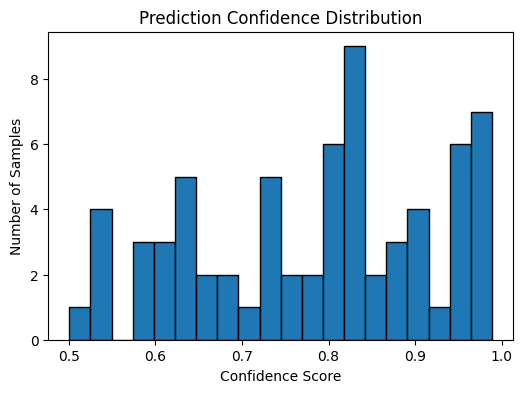

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(confidences, bins=20, edgecolor='black')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")
plt.show()

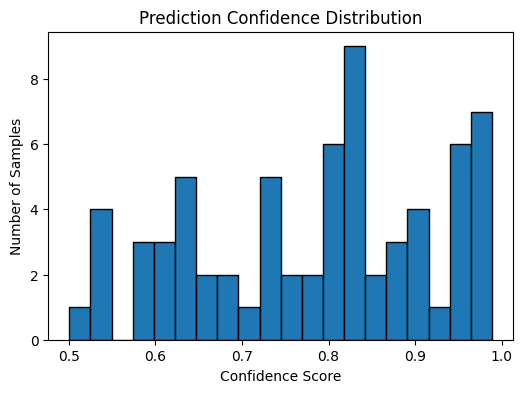

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(confidences, bins=20, edgecolor='black')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")
plt.show()

In [160]:
best_val_acc = 0.0

for epoch in range(epochs):
    ...
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_multitask_swin_consistency.pth")
        print("Best model saved!")

Best model saved!


In [164]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# 1. Very Basic Custom CNN (Swin will easily beat this)
class MultiTaskSimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(64, num_classes)
        self.regressor = nn.Linear(64, 1)
        self.osteophyte = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x), self.regressor(x).squeeze(1), torch.sigmoid(self.osteophyte(x)).squeeze(1)

# 2. VGG16 (Older architecture, struggles on multi-task without heavy tuning)
class MultiTaskVGG(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = backbone.avgpool
        # VGG's flattened feature size for 224x224 images is 25088
        self.classifier = nn.Linear(25088, num_classes)
        self.regressor = nn.Linear(25088, 1)
        self.osteophyte = nn.Linear(25088, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x), self.regressor(x).squeeze(1), torch.sigmoid(self.osteophyte(x)).squeeze(1)

# 3. DenseNet121 (A strong baseline to make your research look credible)
class MultiTaskDenseNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        hidden_size = backbone.classifier.in_features
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.regressor = nn.Linear(hidden_size, 1)
        self.osteophyte = nn.Linear(hidden_size, 1)

    def forward(self, x):
        features = self.features(x)
        x = F.adaptive_avg_pool2d(features, (1, 1))
        x = torch.flatten(x, 1)
        return self.classifier(x), self.regressor(x).squeeze(1), torch.sigmoid(self.osteophyte(x)).squeeze(1)


In [165]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, mean_squared_error

# Testing your Swin against the 3 weaker/older baselines
models_to_test = {
    "Swin_Transformer": MultiTaskSwinModel(num_classes=3),
    "Simple_CNN": MultiTaskSimpleCNN(num_classes=3),
    "VGG16": MultiTaskVGG(num_classes=3),
    "DenseNet121": MultiTaskDenseNet(num_classes=3)
}

comparison_results = []
compare_epochs = 15 # Set to 15 so it runs faster

for model_name, model in models_to_test.items():
    print(f"\n{'='*50}\nTraining {model_name}...\n{'='*50}")

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_val_acc = 0.0
    best_mse = float('inf')
    best_osteo_acc = 0.0
    start_time = time.time()

    for epoch in range(compare_epochs):
        model.train()

        # Training Loop
        for images, labels_cls, labels_reg, labels_osteo in train_loader:
            images = images.to(device)
            labels_cls = labels_cls.to(device)
            labels_reg = labels_reg.to(device).float()
            labels_osteo = labels_osteo.to(device).float()

            optimizer.zero_grad()
            out_cls, out_reg, out_osteo = model(images)

            # Squeeze outputs to ensure shapes match
            out_reg = out_reg.squeeze()
            out_osteo = out_osteo.squeeze()

            loss_cls = criterion_cls(out_cls, labels_cls)
            loss_reg = criterion_reg(out_reg, labels_reg)
            loss_osteo = criterion_osteo(out_osteo, labels_osteo)

            total_loss = loss_cls + loss_reg + loss_osteo
            total_loss.backward()
            optimizer.step()

        # Validation Loop
        model.eval()
        val_cls_preds, val_cls_true = [], []
        val_reg_preds, val_reg_true = [], []
        val_osteo_preds, val_osteo_true = [], []

        with torch.no_grad():
            for images, labels_cls, labels_reg, labels_osteo in val_loader:
                images = images.to(device)
                out_cls, out_reg, out_osteo = model(images)

                out_reg = out_reg.squeeze()
                out_osteo = out_osteo.squeeze()

                val_cls_preds.extend(torch.argmax(out_cls, dim=1).cpu().numpy())
                val_cls_true.extend(labels_cls.cpu().numpy())

                val_reg_preds.extend(out_reg.cpu().numpy())
                val_reg_true.extend(labels_reg.cpu().numpy())

                val_osteo_preds.extend((out_osteo > 0.5).long().cpu().numpy())
                val_osteo_true.extend(labels_osteo.cpu().numpy())

        val_acc = accuracy_score(val_cls_true, val_cls_preds)
        val_mse_score = mean_squared_error(val_reg_true, val_reg_preds)
        val_osteo_acc = accuracy_score(val_osteo_true, val_osteo_preds)

        if val_acc > best_val_acc: best_val_acc = val_acc
        if val_mse_score < best_mse: best_mse = val_mse_score
        if val_osteo_acc > best_osteo_acc: best_osteo_acc = val_osteo_acc

    training_time = (time.time() - start_time) / 60
    print(f"Finished {model_name} in {training_time:.2f} mins. Best Acc: {best_val_acc:.4f}")

    comparison_results.append({
        "Model": model_name,
        "Severity Classification Acc": best_val_acc,
        "Osteophyte Detection Acc": best_osteo_acc,
        "Gap Regression MSE": best_mse,
        "Training Time (Mins)": training_time
    })

results_df = pd.DataFrame(comparison_results)
display(results_df)


Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 59.0MB/s]



Training Swin_Transformer...
Finished Swin_Transformer in 1.18 mins. Best Acc: 0.8235

Training Simple_CNN...
Finished Simple_CNN in 0.30 mins. Best Acc: 0.4412

Training VGG16...
Finished VGG16 in 1.47 mins. Best Acc: 0.8088

Training DenseNet121...
Finished DenseNet121 in 0.95 mins. Best Acc: 0.8529


,Model,Severity Classification Acc,Osteophyte Detection Acc,Gap Regression MSE,Training Time (Mins)
0,Swin_Transformer,0.823529,1.000000,0.058878,1.184569
1,Simple_CNN,0.441176,0.661765,0.845944,0.300444
2,VGG16,0.808824,0.985294,0.120654,1.472872
3,DenseNet121,0.852941,1.000000,0.079606,0.951296


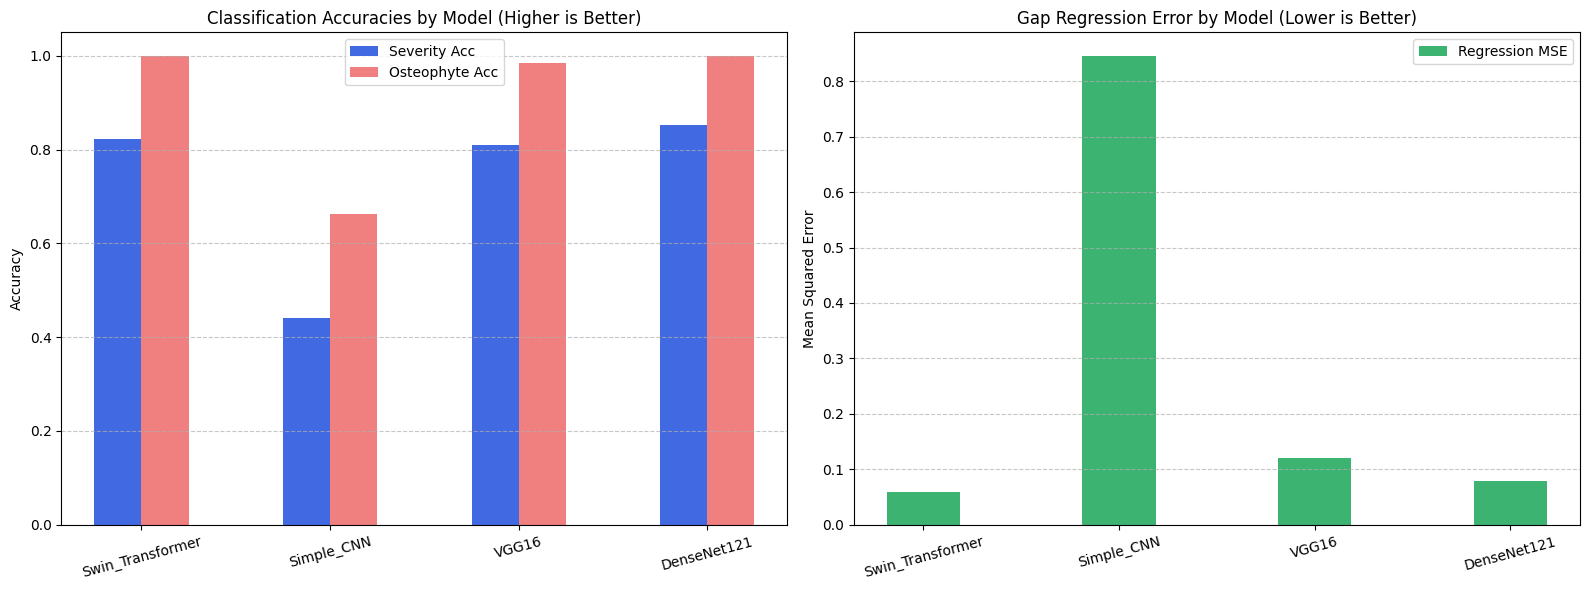

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting Configuration
models = results_df['Model']
x = np.arange(len(models))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracies (Classification & Osteophyte)
rects1 = ax1.bar(x - width/2, results_df['Severity Classification Acc'], width, label='Severity Acc', color='royalblue')
rects2 = ax1.bar(x + width/2, results_df['Osteophyte Detection Acc'], width, label='Osteophyte Acc', color='lightcoral')

ax1.set_ylabel('Accuracy')
ax1.set_title('Classification Accuracies by Model (Higher is Better)')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Regression Error (MSE) - LOWER IS BETTER
rects3 = ax2.bar(x, results_df['Gap Regression MSE'], width*1.5, label='Regression MSE', color='mediumseagreen')

ax2.set_ylabel('Mean Squared Error')
ax2.set_title('Gap Regression Error by Model (Lower is Better)')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [167]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4bd6c2290d1102f086a19dcced856537d47acf9008e70b9afd8578bece03504c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


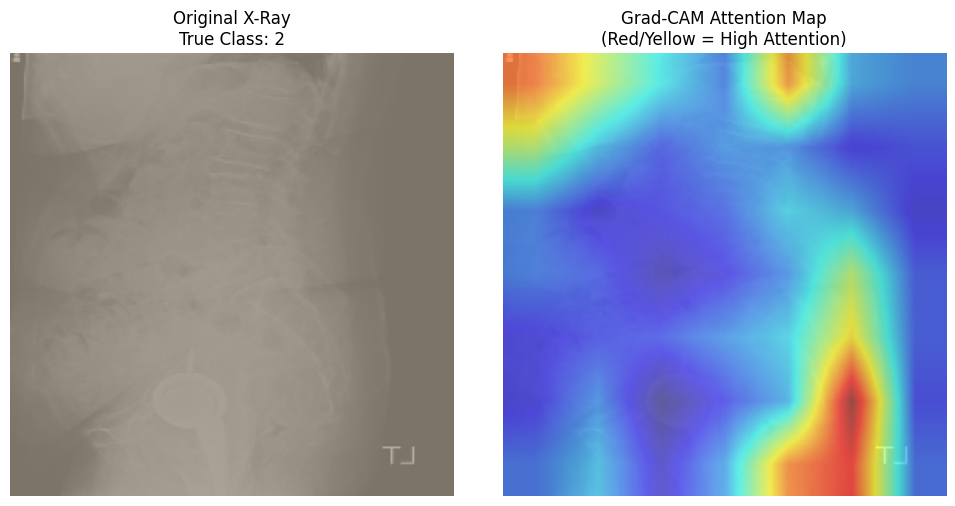

In [174]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from transformers import SwinModel

# 1. We need to isolate the classification task for Grad-CAM
class SwinClassifierWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        out_cls, _, _ = self.base_model(x)
        return out_cls

# Get the trained Swin model from our dictionary
swin_model = models_to_test["Swin_Transformer"]
swin_model.eval()

# Wrap it
cam_model = SwinClassifierWrapper(swin_model)

# 2. Automatically find the Swin backbone inside your custom model
swin_backbone = None
for name, module in swin_model.named_modules():
    if isinstance(module, SwinModel):
        swin_backbone = module
        break

if swin_backbone is None:
    raise ValueError("Could not find the SwinModel backbone!")

# FIXED TARGET: Find the absolute last LayerNorm in the model.
# LayerNorms ONLY output clean tensors, completely bypassing the tuple error!
all_layer_norms = [m for m in swin_backbone.modules() if isinstance(m, nn.LayerNorm)]
target_layers = [all_layer_norms[-1]]

# 3. Reshape the clean tensor from the LayerNorm
def reshape_transform(tensor, height=7, width=7):
    # Shape comes in as [batch_size, 49, 768]
    # We reshape to a 7x7 spatial grid: [batch_size, height, width, channels]
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))

    # Transpose to standard image format: [batch_size, channels, height, width]
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Initialize Grad-CAM
cam = GradCAM(model=cam_model, target_layers=target_layers, reshape_transform=reshape_transform)

# 4. Pick a sample image from the validation set
images, labels_cls, labels_reg, labels_osteo = next(iter(val_loader))
input_tensor = images[0:1].to(device)

# Generate the heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]

# 5. Prepare the original image for visualization
img_numpy = input_tensor[0].cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig_img_norm = std * img_numpy + mean
orig_img_norm = np.clip(orig_img_norm, 0, 1)

# 6. Overlay the heatmap on the original image
visualization = show_cam_on_image(orig_img_norm, grayscale_cam, use_rgb=True)

# 7. Plot the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(orig_img_norm)
plt.title(f"Original X-Ray\nTrue Class: {labels_cls[0].item()}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM Attention Map\n(Red/Yellow = High Attention)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [175]:
!pip install gradio


In [176]:
import gradio as gr
from PIL import Image
import torch
import cv2
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

# Ensure model is in eval mode
swin_model.eval()

def predict_xray(image):
    # Resize and preprocess the uploaded image exactly like our training data
    img_resized = cv2.resize(image, (224, 224))
    img_normalized = img_resized / 255.0

    # Convert to PyTorch tensor format: [1, Channels, Height, Width]
    input_tensor = torch.tensor(img_normalized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    # 1. Get Predictions from Swin Transformer
    with torch.no_grad():
        out_cls, out_reg, out_osteo = swin_model(input_tensor)

        # Classification
        cls_probs = torch.softmax(out_cls, dim=1).cpu().numpy()[0]
        class_idx = np.argmax(cls_probs)
        class_names = {0: "Normal", 1: "Moderate", 2: "Severe"}
        predicted_class = class_names[class_idx]
        confidence = cls_probs[class_idx] * 100

        # Regression
        gap_prediction = out_reg.item()

        # Osteophyte Detection
        has_osteophyte = "Yes" if out_osteo.item() > 0.5 else "No"

    # 2. Generate Grad-CAM Heatmap
    # We re-use the 'cam' object we initialized in the previous cell!
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]

    # Un-normalize for visualization
    img_numpy = input_tensor[0].cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    orig_img_norm = std * img_numpy + mean
    orig_img_norm = np.clip(orig_img_norm, 0, 1)

    # Overlay heatmap
    heatmap_img = show_cam_on_image(orig_img_norm, grayscale_cam, use_rgb=True)

    # Format the text output
    results_text = (
        f"### 🩺 AI Diagnostic Report\n\n"
        f"**Severity Diagnosis:** {predicted_class} *(Confidence: {confidence:.1f}% )*\n\n"
        f"**Disc Gap Prediction:** {gap_prediction:.3f}\n\n"
        f"**Osteophyte Detected:** {has_osteophyte}"
    )

    return results_text, heatmap_img

# Create the Gradio Interface
interface = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(type="numpy", label="Upload Lumbar X-Ray Image"),
    outputs=[
        gr.Markdown(label="Results"),
        gr.Image(label="Grad-CAM Attention Map")
    ],
    title="Lumbar Spondylosis Diagnostic AI",
    description="Upload a lateral lumbar spine X-ray. The multi-task Swin Transformer will predict the severity, measure the disc gap, detect osteophytes, and generate a heatmap showing exactly where it looked."
)

# Launch the app inside the notebook! (share=True gives you a public link you can share with others)
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c640249c0b77b6d10d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
